# Example 8b — MNIST-CP target-conditioned Wasserstein score fields

This notebook replaces the label-only MNIST-CP score model from Example 8 with a target-shape-conditioned model.  The learned field is

\[
S_	heta(	ilde x_i, 	ilde X, 	au, z), \qquad z=f_\phi(X_{
m target}),
\]

so the score for particle `i` receives the individual current location, the full current empirical measure, the diffusion time, and a latent code for the target contour.  This keeps the experiment close to the finite-particle Wasserstein h-transform picture, where the drift is `2 D log u`, while borrowing the ShapeGF idea of shape latents and multi-scale denoising.

The notebook has two stages:

1. Train a target-conditioned score autoencoder/reconstructor.
2. Fit a latent prior over encoded target shapes, then generate new contours by sampling a latent and running the same target-conditioned dynamics.


## Imports

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(torch.cuda.get_device_properties(0))

CUDA available: True
GPU: NVIDIA H200
_CudaDeviceProperties(name='NVIDIA H200', major=9, minor=0, total_memory=143155MB, multi_processor_count=132)


In [2]:
from __future__ import annotations

from pathlib import Path
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mnist.conditioned_diffusion import GeneratedPointCloudSet
from mnist.mnist_cp import (
    load_mnist_cp_splits,
    pairwise_chamfer_distance_matrix,
    one_nn_leave_one_out_chamfer,
    coverage_unique_argmin_chamfer,
    unit_square_to_mnist_cp_points,
)
from mnist.target_conditioned_score import (
    LatentCritic,
    LatentGenerator,
    TargetConditionedScoreModel,
    encode_target_latents,
    evaluate_hybrid_oracle_neural_reconstruction,
    evaluate_model_vs_mixture_oracle,
    evaluate_target_conditioned_score_model,
    fit_score_calibration_against_mixture_oracle,
    fit_gaussian_latent_prior,
    make_sigma_tau_schedule,
    paired_chamfer_reconstruction_metrics,
    perturb_target_conditioned_positions,
    reconstruct_target_conditioned_point_clouds,
    sample_oracle_mixture_annealed_dynamics,
    sample_gaussian_latent_prior,
    sample_target_conditioned_annealed_dynamics,
    sample_wgan_latent_prior,
    train_latent_wgan_gp,
    train_target_conditioned_score_model,
)

SEED = 1234
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("repo root:", REPO_ROOT)
print("device:", DEVICE)


repo root: /workspace/condition_df
device: cuda


In [3]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(SEED)


## Configuration

The default full setting uses all 800 MNIST-CP contour points and a ShapeGF-style geometric noise schedule, converted to the finite-particle `tau` variable by

\[
	au = 

rac{\sigma_{[0,1]}^2}{2K}.
\]

For a quick CPU smoke run, set `FAST_DEMO = True`.

In [4]:
FAST_DEMO = False

MNIST_CP_PATH = REPO_ROOT / "mnist_data" / "mnist_cp.npz"

if FAST_DEMO:
    TRAIN_PER_CLASS = 128
    VAL_PER_CLASS = 32
    TEST_PER_CLASS = 32
    POINTS_PER_CLOUD = 256

    SCORE_EPOCHS = 12
    SCORE_BATCH_SIZE = 16
    RECONSTRUCTION_COUNT = 20
    SYNTHETIC_PER_CLASS = 4

    Z_DIM = 64
    TARGET_ENCODER_HIDDEN_DIM = 128
    SCORE_GRID_SIZE = 32
    SCORE_BASE_CHANNELS = 24
    SCORE_GRID_FEATURE_DIM = 48
    SET_FEATURE_DIM = 64
    SET_HIDDEN_DIM = 64
    SCORE_HIDDEN_DIM = 128

    SIGMA_MAX = 0.20
    SIGMA_MIN = 0.01
    NUM_SIGMA_LEVELS = 6
    STEPS_PER_LEVEL = 4
    RUN_LATENT_WGAN = False
    LATENT_WGAN_EPOCHS = 20

    SCORE_CALIBRATION_MAX_SAMPLES = 24
    HYBRID_BISECTION_MAX_SAMPLES = 8
else:
    TRAIN_PER_CLASS = 2000
    VAL_PER_CLASS = 250
    TEST_PER_CLASS = 250
    POINTS_PER_CLOUD = None  # all saved MNIST-CP points, usually 800

    # The loss in previous runs plateaued early; longer training did not fix sampler collapse.
    # Use early stopping and focus on training states that the sampler actually visits.
    SCORE_EPOCHS = 80
    SCORE_BATCH_SIZE = 32
    RECONSTRUCTION_COUNT = 64
    SYNTHETIC_PER_CLASS = 64

    Z_DIM = 128
    TARGET_ENCODER_HIDDEN_DIM = 256
    SCORE_GRID_SIZE = 64
    SCORE_BASE_CHANNELS = 48
    SCORE_GRID_FEATURE_DIM = 96
    SET_FEATURE_DIM = 128
    SET_HIDDEN_DIM = 128
    SCORE_HIDDEN_DIM = 256

    # Start with a milder largest scale. After real-z reconstruction works, try SIGMA_MAX=0.50.
    SIGMA_MAX = 0.25
    SIGMA_MIN = 0.005
    NUM_SIGMA_LEVELS = 10
    STEPS_PER_LEVEL = 10
    RUN_LATENT_WGAN = False
    LATENT_WGAN_EPOCHS = 1000

    SCORE_CALIBRATION_MAX_SAMPLES = 128
    HYBRID_BISECTION_MAX_SAMPLES = 24

SCORE_LR = 1e-3
ENCODER_LR = 1e-3
WEIGHT_DECAY = 1e-4
DSM_PROJECTION = "none"  # Euclidean-cover noising target.
STATE_PROJECTION = "none"  # Do not clip dynamics; clip only for rasterization/plots if needed.
TIME_WEIGHTING = "none"  # scaled target is -eps, so extra tau weighting is unnecessary.

# ShapeGF-style annealed sampler: noise step, then physical-score gradient step.
SAMPLER_SCHEME = "shape_gf_langevin"  # compare with "theory_euler" and "bridge" as ablations.
LANGEVIN_ALPHA = 5e-5
DIFFUSION_TEMPERATURE = 1.0
SCORE_SCALE = 1.0
FINAL_POLISH_STEPS = 0

# Mixed objective: paired DSM + direct mixture queries + oracle trajectory replay.
# Replay distills the exact empirical-mixture field on states that the successful oracle sampler visits.
DIRECT_MIXTURE_PROBABILITY = 0.25
ORACLE_REPLAY_PROBABILITY = 0.50
ORACLE_REPLAY_WEIGHT = 2.0
ORACLE_REPLAY_STEPS_PER_LEVEL = 2
ORACLE_REPLAY_MAX_LEVELS = None
DIRECT_QUERY_MODES = ("noised_target", "uniform", "center_gaussian")
ORACLE_REPLAY_INITIAL_MODES = ("uniform", "center_gaussian", "fixed_center")
DIRECT_QUERY_CENTER_STD = 0.35
MIXTURE_CHUNK_SIZE = 256
MIXTURE_TARGET_NORM_CLIP = None

# The target latent z is now a global code plus an optional target raster feature field.
USE_TARGET_GRID_CONDITIONING = True
TARGET_GRID_FEATURE_DIM = SCORE_GRID_FEATURE_DIM

# Pointwise field leads; measure-aware branch is a capped, learned gated residual correction.
USE_MEASURE_RESIDUAL = True
MEASURE_GATE_INIT = -5.0
MEASURE_GATE_MAX = 0.10
MEASURE_GATE_REGULARIZATION = 1e-2
FREEZE_MEASURE_BRANCH_EPOCHS = 20

# Per-sigma calibration/clipping against the empirical-mixture oracle.
USE_SCORE_CALIBRATION = True
USE_SCORE_CLIPPING = True
SCORE_CALIBRATION_QUERY_MODES = ("uniform", "center_gaussian", "noised_target")
SCORE_CALIBRATION_CLIP_QUANTILE = 0.99

# Hybrid bisection: oracle for first m sigma levels, then neural. This localizes where collapse begins.
RUN_HYBRID_BISECTION_DIAGNOSTIC = True
HYBRID_PREFIX_LEVELS = (0, 1, 2, 3, 5, NUM_SIGMA_LEVELS)
HYBRID_SUFFIX_LEVELS = ()

EARLY_STOPPING_PATIENCE = 20
LR_SCHEDULER_PATIENCE = 10
LR_SCHEDULER_FACTOR = 0.5
MIN_LR = 1e-5

GAUSSIAN_LATENT_DIAGONAL = True
LATENT_NOISE_DIM = 128
LATENT_WGAN_BATCH_SIZE = 128
LATENT_WGAN_LR = 1e-4
LATENT_WGAN_CRITIC_STEPS = 5
LATENT_WGAN_GP = 10.0

print("FAST_DEMO =", FAST_DEMO)
print("MNIST-CP path =", MNIST_CP_PATH)
print("train/val/test per class =", (TRAIN_PER_CLASS, VAL_PER_CLASS, TEST_PER_CLASS))
print("points per cloud =", POINTS_PER_CLOUD if POINTS_PER_CLOUD is not None else "all saved")
print("sampler =", SAMPLER_SCHEME, "alpha =", LANGEVIN_ALPHA, "temperature =", DIFFUSION_TEMPERATURE)
print("training probabilities: paired/direct/replay =", (1.0 - DIRECT_MIXTURE_PROBABILITY - ORACLE_REPLAY_PROBABILITY, DIRECT_MIXTURE_PROBABILITY, ORACLE_REPLAY_PROBABILITY))
print("target grid conditioning =", USE_TARGET_GRID_CONDITIONING)
print("measure gate init/max =", (MEASURE_GATE_INIT, MEASURE_GATE_MAX))
print("score calibration/clipping =", (USE_SCORE_CALIBRATION, USE_SCORE_CLIPPING))
print("latent WGAN enabled =", RUN_LATENT_WGAN)


FAST_DEMO = False
MNIST-CP path = /workspace/condition_df/mnist_data/mnist_cp.npz
train/val/test per class = (2000, 250, 250)
points per cloud = all saved
sampler = shape_gf_langevin alpha = 5e-05 temperature = 1.0
training probabilities: paired/direct/replay = (0.25, 0.25, 0.5)
target grid conditioning = True
measure gate init/max = (-5.0, 0.1)
score calibration/clipping = (True, True)
latent WGAN enabled = False


## Load MNIST-CP

In [5]:
splits = load_mnist_cp_splits(
    MNIST_CP_PATH,
    train_per_class=TRAIN_PER_CLASS,
    val_per_class=VAL_PER_CLASS,
    test_per_class=TEST_PER_CLASS,
    num_points=POINTS_PER_CLOUD,
    seed=SEED,
    load_images=True,
)
train_pc = splits.train
val_pc = splits.val
reference_pc = splits.test
K = int(train_pc.positions.shape[1])
print("normalization in file:", splits.normalization)
print("train positions:", train_pc.positions.shape, "labels:", np.bincount(train_pc.labels, minlength=10))
print("val positions:", val_pc.positions.shape, "labels:", np.bincount(val_pc.labels, minlength=10))
print("reference positions:", reference_pc.positions.shape, "labels:", np.bincount(reference_pc.labels, minlength=10))
print("K =", K)


normalization in file: bbox_centered_longest_side_to_[-1,1]
train positions: (20000, 800, 2) labels: [2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]
val positions: (2500, 800, 2) labels: [250 250 250 250 250 250 250 250 250 250]
reference positions: (2500, 800, 2) labels: [250 250 250 250 250 250 250 250 250 250]
K = 800


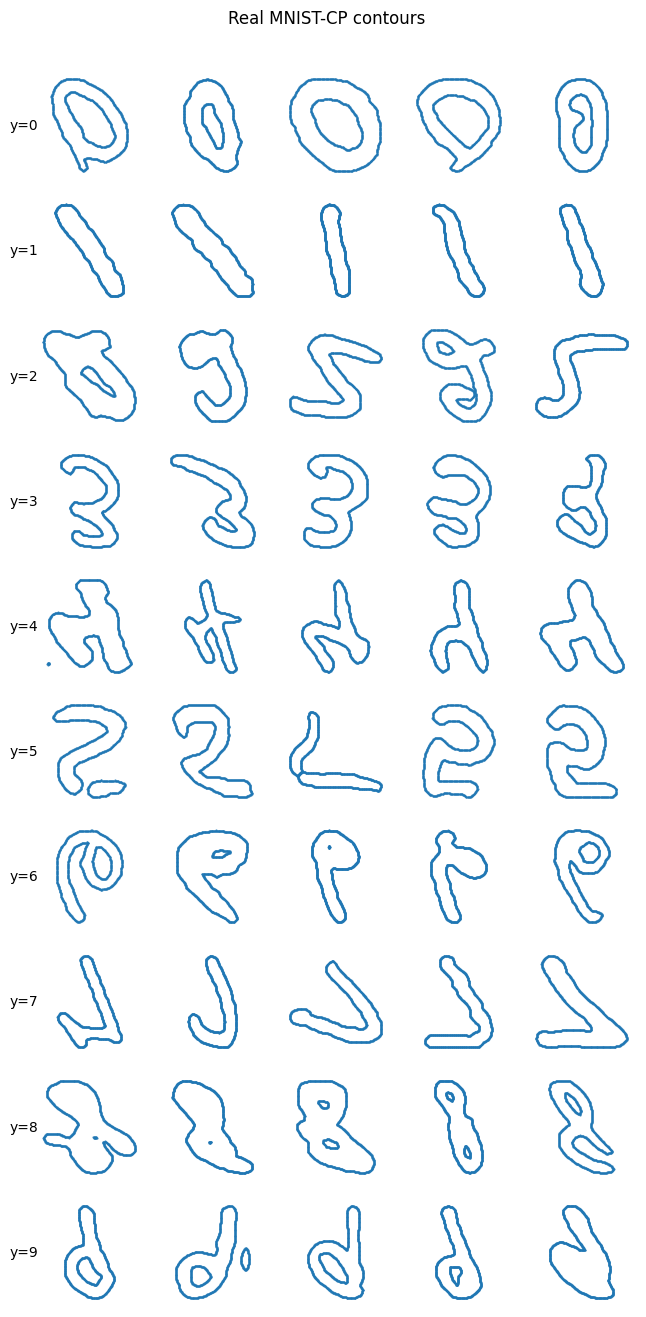

In [6]:
def plot_mnist_cp_gallery(
    positions: np.ndarray,
    labels: np.ndarray,
    *,
    examples_per_label: int = 4,
    title: str | None = None,
    seed: int = 0,
    point_size: float | None = None,
) -> None:
    rng = np.random.default_rng(seed)
    labels_arr = np.asarray(labels, dtype=np.int64)
    unique_labels = np.unique(labels_arr)
    rows = len(unique_labels)
    cols = int(examples_per_label)
    fig, axes = plt.subplots(rows, cols, figsize=(1.3 * cols, 1.3 * rows), squeeze=False)
    for row, label in enumerate(unique_labels):
        idx = np.flatnonzero(labels_arr == label)
        chosen = rng.choice(idx, size=min(cols, len(idx)), replace=False)
        for col in range(cols):
            ax = axes[row, col]
            ax.axis("off")
            ax.set_aspect("equal")
            ax.set_xlim(-0.10, 1.10)
            ax.set_ylim(1.10, -0.10)
            if col < len(chosen):
                pts = positions[chosen[col]]
                size = point_size if point_size is not None else (0.35 if pts.shape[0] > 300 else 1.0)
                ax.scatter(pts[:, 0], pts[:, 1], s=size, alpha=0.80)
            if col == 0:
                ax.text(-0.22, 0.5, f"y={int(label)}", transform=ax.transAxes, va="center")
    if title is not None:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()


plot_mnist_cp_gallery(train_pc.positions, train_pc.labels, examples_per_label=5, title="Real MNIST-CP contours")


## Multi-scale tau schedule

In [7]:
sigma_levels, tau_levels = make_sigma_tau_schedule(
    num_points=K,
    num_levels=NUM_SIGMA_LEVELS,
    sigma_max=SIGMA_MAX,
    sigma_min=SIGMA_MIN,
)
schedule_df = pd.DataFrame(
    {
        "level": np.arange(len(sigma_levels)),
        "sigma_unit_square": sigma_levels,
        "sigma_pixels": 28.0 * sigma_levels,
        "tau": tau_levels,
    }
)
TAU_MIN = float(np.min(tau_levels))
TAU_MAX = float(np.max(tau_levels))
print("tau range:", (TAU_MIN, TAU_MAX))
schedule_df


tau range: (1.5625e-08, 3.90625e-05)


,level,sigma_unit_square,sigma_pixels,tau
0,0,0.250000,7.000000,3.906250e-05
1,1,0.161870,4.532352,1.637613e-05
2,2,0.104807,2.934602,6.865343e-06
3,3,0.067860,1.900092,2.878150e-06
4,4,0.043938,1.230270,1.206603e-06
5,5,0.028449,0.796573,5.058428e-07
6,6,0.018420,0.515764,2.120639e-07
7,7,0.011927,0.333947,8.890328e-08
8,8,0.007722,0.216223,3.727082e-08
9,9,0.005000,0.140000,1.562500e-08


## Train target-conditioned score autoencoder

The model predicts the scaled score `sqrt(2 tau s_i) S_i`, whose target is `-epsilon_i`.  At sampling time, `model.forward(...)` converts this back to the Wasserstein score `S_i`, and the theory-aligned drift is `2 S_i`.

In [8]:
score_model = TargetConditionedScoreModel(
    latent_dim=Z_DIM,
    target_encoder_hidden_dim=TARGET_ENCODER_HIDDEN_DIM,
    target_encoder_layers=3,
    grid_size=SCORE_GRID_SIZE,
    base_channels=SCORE_BASE_CHANNELS,
    grid_feature_dim=SCORE_GRID_FEATURE_DIM,
    set_feature_dim=SET_FEATURE_DIM,
    set_hidden_dim=SET_HIDDEN_DIM,
    set_blocks=3,
    score_hidden_dim=SCORE_HIDDEN_DIM,
    score_residual_blocks=2,
    time_dim=64,
    context_dim=128 if not FAST_DEMO else 96,
    condition_on_label=True,
    num_classes=10,
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    dropout=0.02,
    use_fourier_features=False,
    include_occupancy_channel=True,
    use_image_field=True,
    use_measure_residual=USE_MEASURE_RESIDUAL,
    use_target_grid_conditioning=USE_TARGET_GRID_CONDITIONING,
    target_grid_feature_dim=TARGET_GRID_FEATURE_DIM,
    measure_gate_init=MEASURE_GATE_INIT,
    measure_gate_max=MEASURE_GATE_MAX,
)
print(score_model)


TargetConditionedScoreModel(
  (target_encoder): TargetPointCloudEncoder(
    (point_mlp): Sequential(
      (0): Linear(in_features=4, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.02, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): GELU(approximate='none')
      (5): Dropout(p=0.02, inplace=False)
      (6): Linear(in_features=256, out_features=256, bias=True)
      (7): GELU(approximate='none')
    )
    (latent_head): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.02, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
    )
    (latent_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (time_mlp): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): G

In [9]:
score_history = train_target_conditioned_score_model(
    score_model,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    val_masses=val_pc.masses,
    val_positions=val_pc.positions,
    val_labels=val_pc.labels,
    tau_levels=tau_levels,
    epochs=SCORE_EPOCHS,
    batch_size=SCORE_BATCH_SIZE,
    lr=SCORE_LR,
    encoder_lr=ENCODER_LR,
    weight_decay=WEIGHT_DECAY,
    projection=DSM_PROJECTION,
    time_weighting=TIME_WEIGHTING,
    direct_mixture_probability=DIRECT_MIXTURE_PROBABILITY,
    oracle_replay_probability=ORACLE_REPLAY_PROBABILITY,
    oracle_replay_weight=ORACLE_REPLAY_WEIGHT,
    oracle_replay_steps_per_level=ORACLE_REPLAY_STEPS_PER_LEVEL,
    oracle_replay_max_levels=ORACLE_REPLAY_MAX_LEVELS,
    oracle_replay_initial_modes=ORACLE_REPLAY_INITIAL_MODES,
    oracle_replay_langevin_alpha=LANGEVIN_ALPHA,
    oracle_replay_diffusion_temperature=DIFFUSION_TEMPERATURE,
    oracle_replay_score_scale=SCORE_SCALE,
    direct_query_modes=DIRECT_QUERY_MODES,
    direct_query_center_std=DIRECT_QUERY_CENTER_STD,
    mixture_chunk_size=MIXTURE_CHUNK_SIZE,
    mixture_target_norm_clip=MIXTURE_TARGET_NORM_CLIP,
    measure_gate_regularization=MEASURE_GATE_REGULARIZATION,
    freeze_measure_branch_epochs=FREEZE_MEASURE_BRANCH_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    min_lr=MIN_LR,
    max_grad_norm=5.0,
    device=DEVICE,
    verbose=True,
)


epoch 0001/80: train_loss=41.2374 val_loss=22.4813 val/zero=0.5840 direct=0.26 replay=0.48 gate=0.000 lr=1.00e-03
epoch 0008/80: train_loss=4.47317 val_loss=3.43852 val/zero=0.0763 direct=0.27 replay=0.49 gate=0.000 lr=1.00e-03
epoch 0016/80: train_loss=3.04153 val_loss=3.42977 val/zero=0.0950 direct=0.24 replay=0.51 gate=0.000 lr=1.00e-03
epoch 0024/80: train_loss=2.83665 val_loss=3.03223 val/zero=0.0560 direct=0.25 replay=0.50 gate=0.048 lr=5.00e-04
epoch 0032/80: train_loss=2.27002 val_loss=1.61756 val/zero=0.0429 direct=0.25 replay=0.49 gate=0.047 lr=5.00e-04
epoch 0040/80: train_loss=1.85195 val_loss=1.68552 val/zero=0.0432 direct=0.23 replay=0.52 gate=0.047 lr=5.00e-04
epoch 0048/80: train_loss=1.56663 val_loss=1.39374 val/zero=0.0470 direct=0.24 replay=0.51 gate=0.047 lr=2.50e-04
epoch 0056/80: train_loss=1.46363 val_loss=1.31967 val/zero=0.0373 direct=0.26 replay=0.50 gate=0.046 lr=2.50e-04
epoch 0064/80: train_loss=1.32741 val_loss=1.24813 val/zero=0.0338 direct=0.27 replay=0.

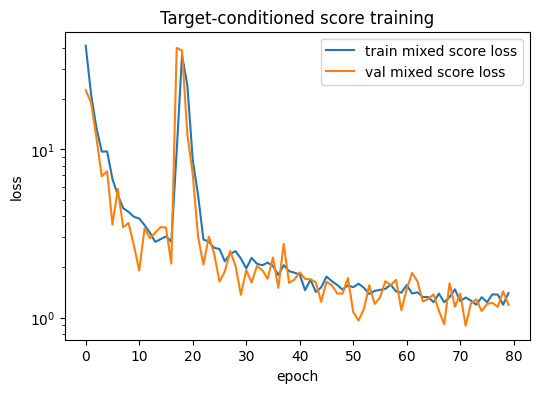

,train_loss,train_sample_loss,train_direct_fraction,train_replay_fraction,val_loss,val_loss_ratio_vs_zero,val_direct_fraction,val_replay_fraction,lr,measure_gate
75,1.236671,1.214654,0.2384,0.5344,1.208635,0.028052,0.2304,0.4880,0.000125,0.045962
76,1.377088,1.358997,0.2656,0.4528,1.227177,0.036123,0.1664,0.4480,0.000125,0.045972
77,1.373745,1.353924,0.2672,0.4672,1.160428,0.025363,0.2704,0.4480,0.000125,0.045970
78,1.195395,1.172697,0.2368,0.5072,1.434193,0.027710,0.2688,0.5376,0.000125,0.045972
79,1.399009,1.377902,0.2656,0.5168,1.194784,0.027565,0.2560,0.4864,0.000125,0.046012


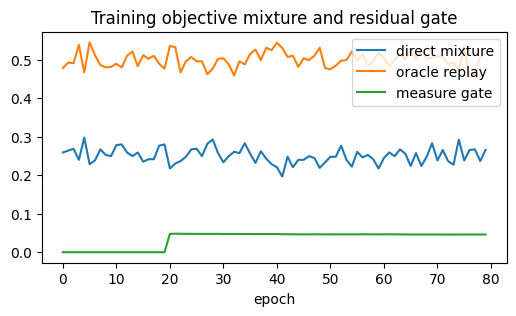

In [10]:
fig = plt.figure(figsize=(6, 4))
plt.plot(score_history["train_loss"], label="train mixed score loss")
if score_history.get("val_loss"):
    plt.plot(score_history["val_loss"], label="val mixed score loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Target-conditioned score training")
plt.show()

history_df = pd.DataFrame({k: v for k, v in score_history.items() if isinstance(v, list) and len(v) == len(score_history["train_loss"])})
display(history_df.tail())

if "train_replay_fraction" in history_df:
    fig = plt.figure(figsize=(6, 3))
    plt.plot(history_df["train_direct_fraction"], label="direct mixture")
    plt.plot(history_df["train_replay_fraction"], label="oracle replay")
    plt.plot(history_df["measure_gate"], label="measure gate")
    plt.xlabel("epoch")
    plt.legend()
    plt.title("Training objective mixture and residual gate")
    plt.show()


## One-step target-conditioned denoising diagnostic

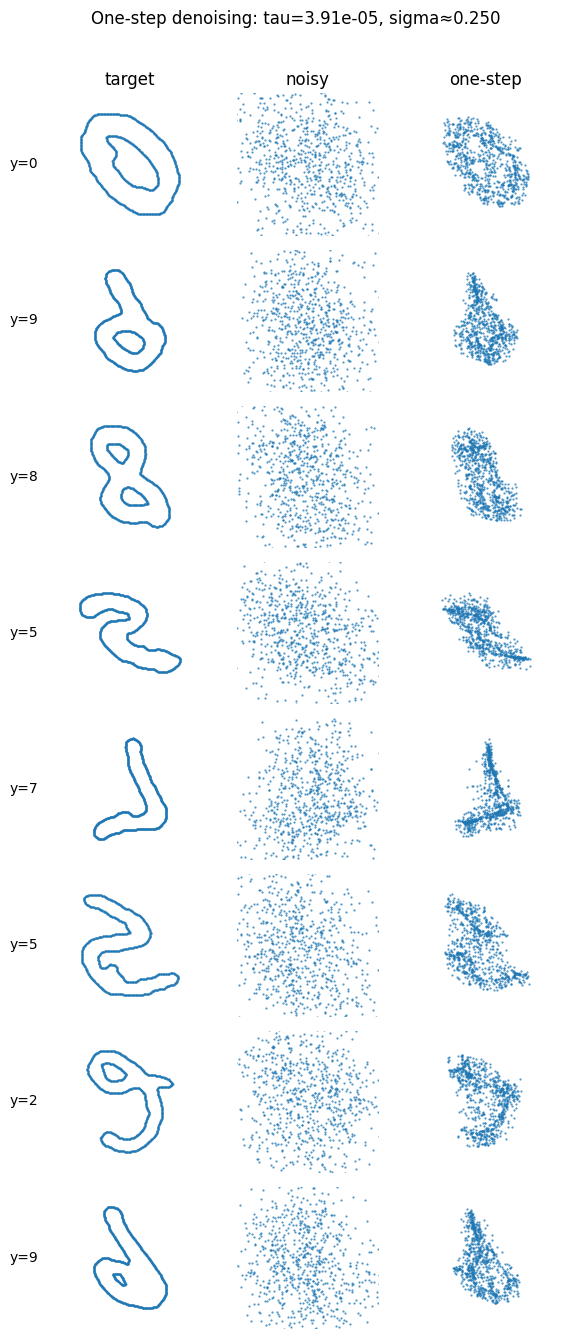

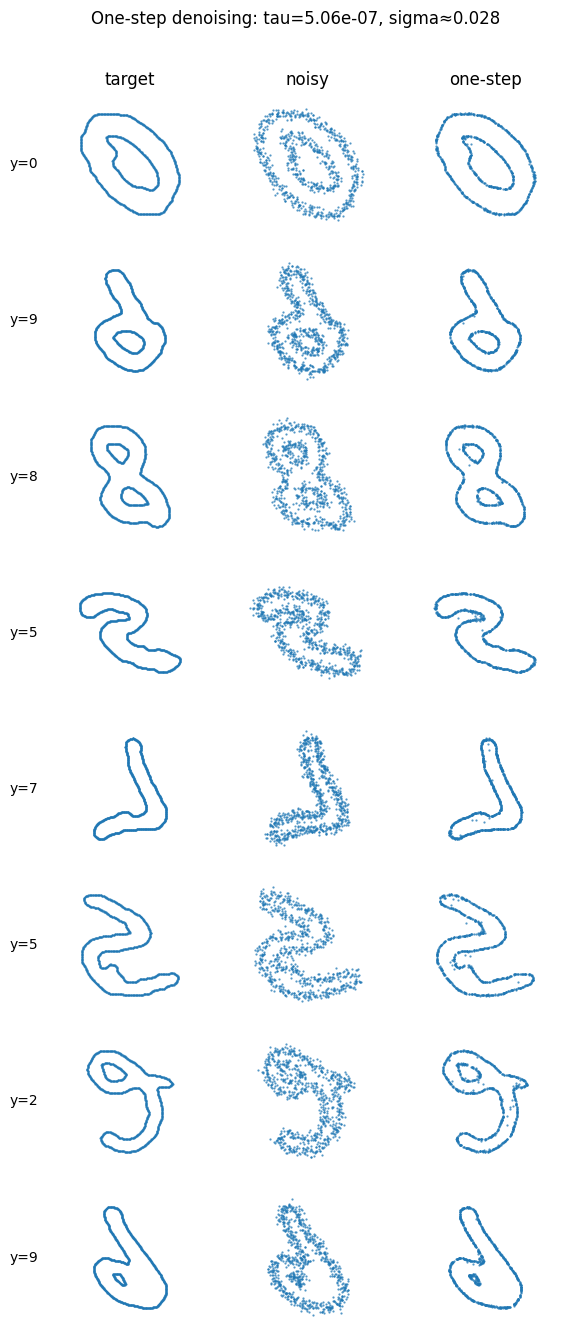

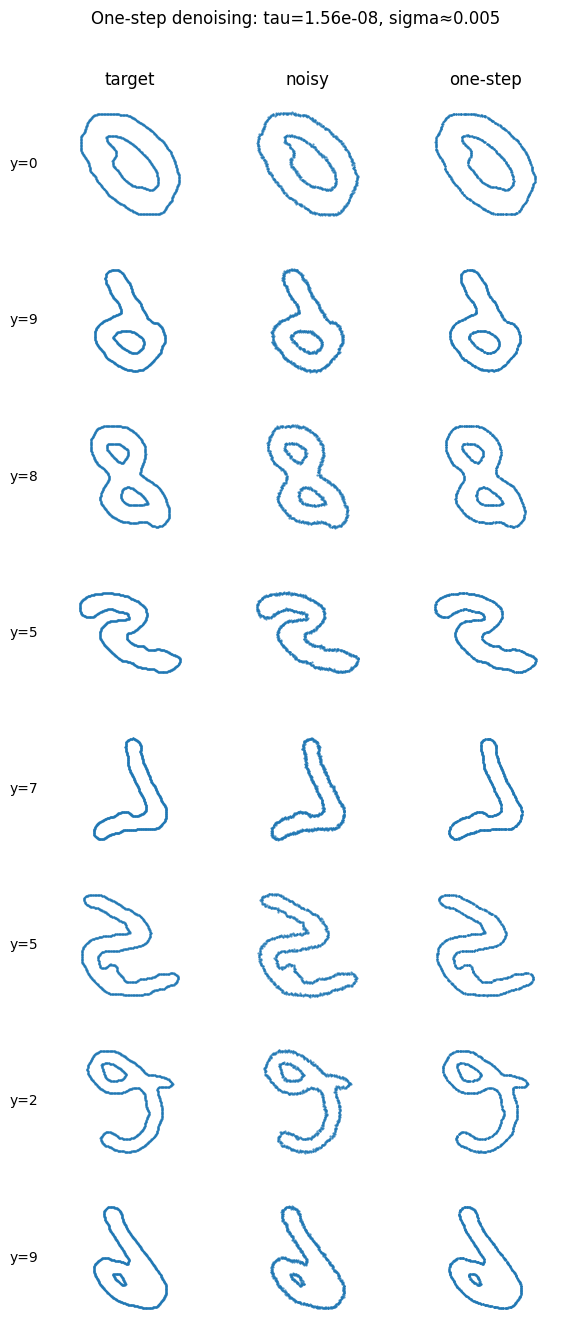

In [11]:
@torch.no_grad()
def one_step_target_denoising_samples(
    model: TargetConditionedScoreModel,
    masses_np: np.ndarray,
    positions_np: np.ndarray,
    labels_np: np.ndarray,
    *,
    tau_value: float,
    count: int = 32,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    idx = np.arange(min(count, len(labels_np)))
    masses = torch.tensor(masses_np[idx], dtype=torch.float32, device=DEVICE)
    clean = torch.tensor(positions_np[idx], dtype=torch.float32, device=DEVICE)
    labels = torch.tensor(labels_np[idx], dtype=torch.long, device=DEVICE)
    tau = torch.full((len(idx),), float(tau_value), dtype=torch.float32, device=DEVICE)
    noisy, target_scaled, _ = perturb_target_conditioned_positions(masses, clean, tau, projection=DSM_PROJECTION)
    score = model(masses, noisy, tau, target_positions=clean, target_masses=masses, labels=labels)
    denoised = noisy + 2.0 * tau[:, None, None] * score
    return (
        clean.detach().cpu().numpy(),
        noisy.detach().cpu().numpy(),
        denoised.detach().cpu().numpy(),
        labels.detach().cpu().numpy(),
    )


def plot_one_step_triplets(clean, noisy, denoised, labels, *, examples: int = 8, title: str | None = None) -> None:
    n = min(examples, len(labels))
    fig, axes = plt.subplots(n, 3, figsize=(6.0, 1.65 * n), squeeze=False)
    for row in range(n):
        for col, (name, arr) in enumerate([("target", clean), ("noisy", noisy), ("one-step", denoised)]):
            ax = axes[row, col]
            pts = arr[row]
            ax.scatter(pts[:, 0], pts[:, 1], s=0.35 if pts.shape[0] > 300 else 1.0, alpha=0.75)
            ax.set_aspect("equal")
            ax.set_xlim(-0.20, 1.20)
            ax.set_ylim(1.20, -0.20)
            ax.axis("off")
            if row == 0:
                ax.set_title(name)
            if col == 0:
                ax.text(-0.35, 0.5, f"y={int(labels[row])}", transform=ax.transAxes, va="center")
    if title is not None:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()


# At the largest noise level the Bayes denoiser need not recover every contour in one step.
# The important diagnostic is that performance improves coherently as sigma decreases.
for tau_value in [tau_levels[0], tau_levels[len(tau_levels)//2], tau_levels[-1]]:
    clean, noisy, denoised, labels_used = one_step_target_denoising_samples(
        score_model,
        val_pc.masses,
        val_pc.positions,
        val_pc.labels,
        tau_value=float(tau_value),
        count=24,
    )
    sigma_unit = float(np.sqrt(2.0 * K * tau_value))
    plot_one_step_triplets(
        clean,
        noisy,
        denoised,
        labels_used,
        examples=8,
        title=f"One-step denoising: tau={tau_value:.2e}, sigma≈{sigma_unit:.3f}",
    )


## Oracle score diagnostics

These diagnostics separate sampler failure from score failure. The empirical Gaussian-mixture oracle is the exact ShapeGF-style contour field for a given target point cloud. If the oracle sampler works but the neural sampler collapses, the model is not matching the field on states visited by the sampler.

In [12]:
diagnostic_tau_levels = np.asarray([tau_levels[0], tau_levels[len(tau_levels)//2], tau_levels[-1]], dtype=np.float64)
oracle_diag_rows = evaluate_model_vs_mixture_oracle(
    score_model,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    tau_levels=diagnostic_tau_levels,
    query_modes=DIRECT_QUERY_MODES,
    max_samples=64 if not FAST_DEMO else 16,
    batch_size=SCORE_BATCH_SIZE,
    mixture_chunk_size=MIXTURE_CHUNK_SIZE,
    projection=DSM_PROJECTION,
    device=DEVICE,
)
oracle_diag_df = pd.DataFrame(oracle_diag_rows)
oracle_diag_df

,tau,sigma_approx,query_mode,physical_score_rmse,relative_rmse,cosine
0,3.906250e-05,0.250000,noised_target,0.363057,0.123928,0.992313
1,3.906250e-05,0.250000,uniform,0.351908,0.155642,0.987814
2,3.906250e-05,0.250000,center_gaussian,0.406778,0.132156,0.991393
3,5.058428e-07,0.028449,noised_target,2.248356,0.096164,0.995406
4,5.058428e-07,0.028449,uniform,14.726129,0.131572,0.991432
5,5.058428e-07,0.028449,center_gaussian,26.129951,0.140290,0.990407
6,1.562500e-08,0.005000,noised_target,38.331667,0.272729,0.964064
7,1.562500e-08,0.005000,uniform,589.365557,0.161577,0.986906
8,1.562500e-08,0.005000,center_gaussian,929.022643,0.153517,0.988148


## Score calibration and hybrid diagnostics

Fit a scalar physical-score calibration and optional norm clipping for each sigma level by comparing the neural field against the exact empirical-mixture oracle. Then use hybrid oracle/neural reconstructions to identify which noise levels are causing collapse.

In [13]:
if USE_SCORE_CALIBRATION:
    score_calibration = fit_score_calibration_against_mixture_oracle(
        score_model,
        val_pc.masses,
        val_pc.positions,
        val_pc.labels,
        tau_levels=tau_levels,
        query_modes=SCORE_CALIBRATION_QUERY_MODES,
        max_samples=SCORE_CALIBRATION_MAX_SAMPLES,
        batch_size=SCORE_BATCH_SIZE,
        mixture_chunk_size=MIXTURE_CHUNK_SIZE,
        projection=DSM_PROJECTION,
        clip_quantile=SCORE_CALIBRATION_CLIP_QUANTILE if USE_SCORE_CLIPPING else None,
        device=DEVICE,
    )
    calibration_df = pd.DataFrame({
        "level": np.arange(len(score_calibration.tau_levels)),
        "tau": score_calibration.tau_levels,
        "sigma_unit_square": np.sqrt(2.0 * K * score_calibration.tau_levels),
        "physical_score_scale": score_calibration.physical_score_scale,
        "physical_norm_clip": score_calibration.physical_norm_clip,
    })
    score_norm_clip = score_calibration.physical_norm_clip if USE_SCORE_CLIPPING else None
    display(calibration_df)
else:
    score_calibration = None
    score_norm_clip = None
    calibration_df = None
    print("Skipping score calibration.")


,level,tau,sigma_unit_square,physical_score_scale,physical_norm_clip
0,0,3.906250e-05,0.250000,1.009563,10.418802
1,1,1.637613e-05,0.161870,1.009019,21.829665
2,2,6.865343e-06,0.104807,1.016579,50.988705
3,3,2.878150e-06,0.067860,1.007101,120.780490
4,4,1.206603e-06,0.043938,1.009049,287.223693
5,5,5.058428e-07,0.028449,1.023662,686.528406
6,6,2.120639e-07,0.018420,1.016116,1630.558547
7,7,8.890328e-08,0.011927,1.017746,3926.327754
8,8,3.727082e-08,0.007722,1.004275,9400.459521
9,9,1.562500e-08,0.005000,1.000745,22070.610449


## Target-conditioned reconstruction from a simple prior

In [14]:
recon_idx = np.arange(min(RECONSTRUCTION_COUNT, len(val_pc.labels)))
reconstruction = reconstruct_target_conditioned_point_clouds(
    score_model,
    val_pc.masses[recon_idx],
    val_pc.positions[recon_idx],
    val_pc.labels[recon_idx],
    tau_levels=tau_levels,
    steps_per_level=STEPS_PER_LEVEL,
    sampler_scheme=SAMPLER_SCHEME,
    initial_position_mode="uniform",
    state_projection=STATE_PROJECTION,
    score_scale=SCORE_SCALE,
    diffusion_temperature=DIFFUSION_TEMPERATURE,
    final_polish_steps=FINAL_POLISH_STEPS,
    langevin_alpha=LANGEVIN_ALPHA,
    score_calibration=score_calibration,
    score_norm_clip=score_norm_clip,
    batch_size=SCORE_BATCH_SIZE,
    rasterize=False,
    return_trajectories=True,
    device=DEVICE,
    rng=np.random.default_rng(SEED + 10),
)
print(reconstruction.positions.shape)


(64, 800, 2)


,value
mean_chamfer,0.000012
median_chamfer,0.000011
std_chamfer,0.000004
squared_chamfer,True


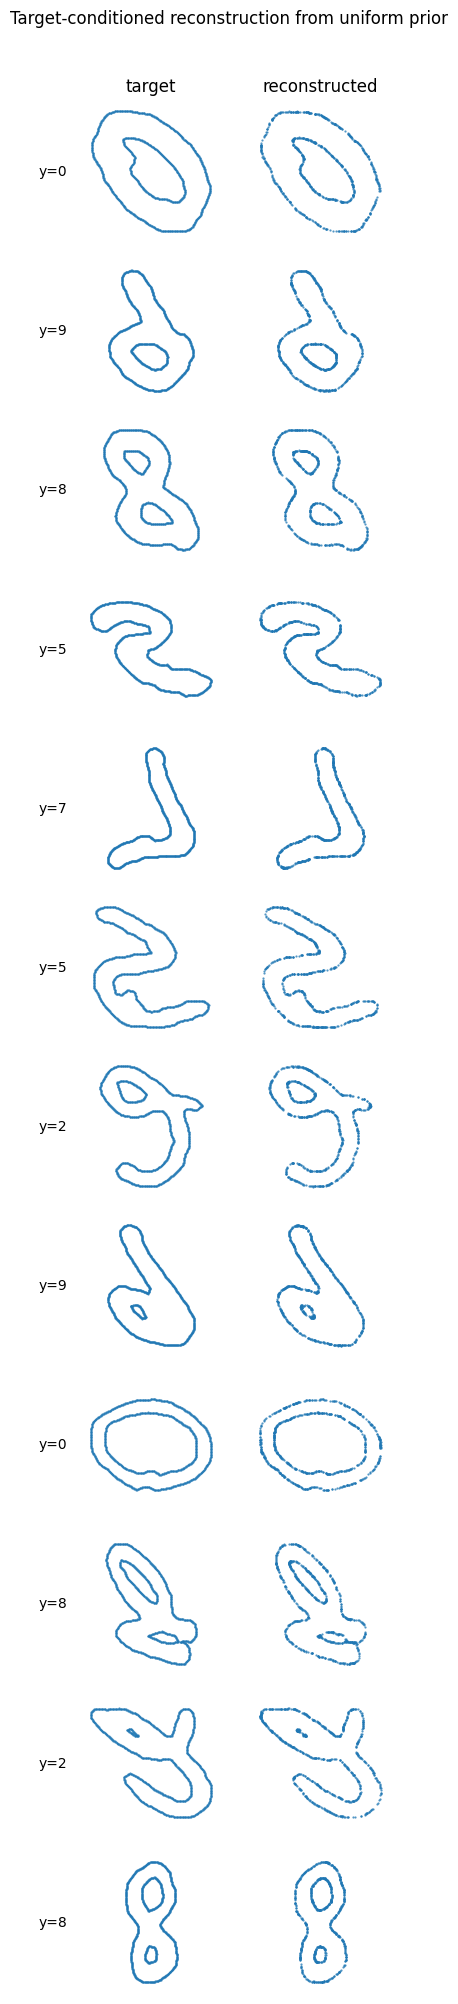

In [15]:
def plot_reconstruction_pairs(target_positions, generated_positions, labels, *, count: int = 10, title: str | None = None) -> None:
    n = min(count, len(labels))
    fig, axes = plt.subplots(n, 2, figsize=(4.0, 1.65 * n), squeeze=False)
    for row in range(n):
        for col, (name, arr) in enumerate([("target", target_positions), ("reconstructed", generated_positions)]):
            ax = axes[row, col]
            pts = arr[row]
            ax.scatter(pts[:, 0], pts[:, 1], s=0.35 if pts.shape[0] > 300 else 1.0, alpha=0.75)
            ax.set_aspect("equal")
            ax.set_xlim(-0.10, 1.10)
            ax.set_ylim(1.10, -0.10)
            ax.axis("off")
            if row == 0:
                ax.set_title(name)
            if col == 0:
                ax.text(-0.28, 0.5, f"y={int(labels[row])}", transform=ax.transAxes, va="center")
    if title is not None:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()


plot_reconstruction_pairs(
    val_pc.positions[recon_idx],
    reconstruction.positions,
    val_pc.labels[recon_idx],
    count=12,
    title="Target-conditioned reconstruction from uniform prior",
)

recon_metrics = paired_chamfer_reconstruction_metrics(
    reconstruction.positions,
    val_pc.positions[recon_idx],
    val_pc.labels[recon_idx],
    squared=True,
)
recon_summary = {k: v for k, v in recon_metrics.items() if k not in {"per_sample_chamfer", "per_label"}}
pd.DataFrame([recon_summary]).T.rename(columns={0: "value"})


,value
mean_chamfer,0.000008
median_chamfer,0.000008
std_chamfer,0.000002
squared_chamfer,True


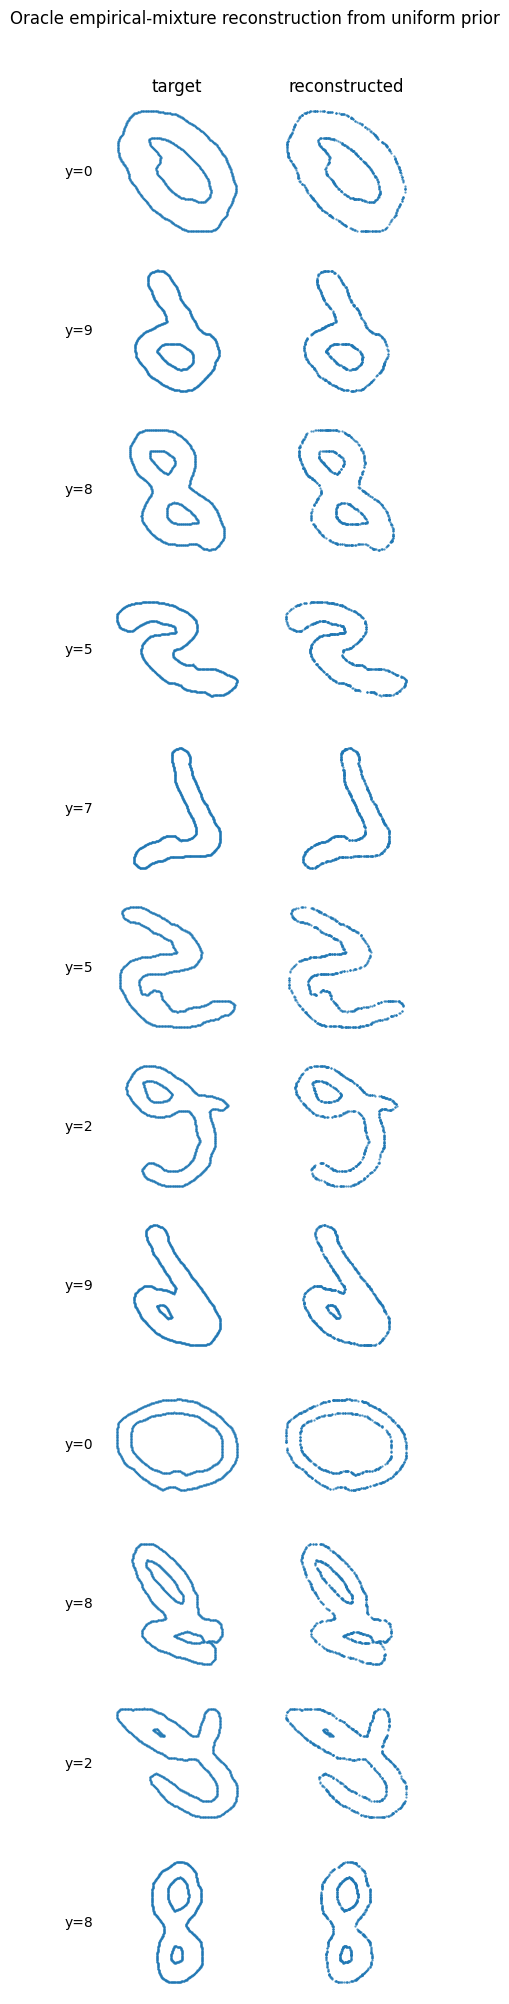

In [16]:
# Oracle reconstruction: same sampler, but with the exact empirical mixture score instead of the neural score.
# If this looks good and the neural reconstruction does not, improve training/model before touching the latent prior.
oracle_reconstruction = sample_oracle_mixture_annealed_dynamics(
    target_masses=val_pc.masses[recon_idx],
    target_positions=val_pc.positions[recon_idx],
    labels=val_pc.labels[recon_idx],
    tau_levels=tau_levels,
    steps_per_level=STEPS_PER_LEVEL,
    initial_position_mode="uniform",
    state_projection=STATE_PROJECTION,
    score_scale=SCORE_SCALE,
    diffusion_temperature=DIFFUSION_TEMPERATURE,
    final_polish_steps=FINAL_POLISH_STEPS,
    langevin_alpha=LANGEVIN_ALPHA,
    batch_size=SCORE_BATCH_SIZE,
    rasterize=False,
    return_trajectories=False,
    device=DEVICE,
    rng=np.random.default_rng(SEED + 11),
)
plot_reconstruction_pairs(
    val_pc.positions[recon_idx],
    oracle_reconstruction.positions,
    val_pc.labels[recon_idx],
    count=12,
    title="Oracle empirical-mixture reconstruction from uniform prior",
)
oracle_recon_metrics = paired_chamfer_reconstruction_metrics(
    oracle_reconstruction.positions,
    val_pc.positions[recon_idx],
    val_pc.labels[recon_idx],
    squared=True,
)
pd.DataFrame([{k: v for k, v in oracle_recon_metrics.items() if k not in {"per_sample_chamfer", "per_label"}}]).T.rename(columns={0: "value"})

## Hybrid oracle/neural reconstruction bisection

These rows answer: how many early high-noise levels need the oracle before the neural field can finish the reconstruction? If `oracle_levels=1` or `2` fixes collapse, the high-sigma global field is the bottleneck; if only full oracle works, mid/fine off-trajectory fields are still unreliable.

In [17]:
if RUN_HYBRID_BISECTION_DIAGNOSTIC:
    hybrid_rows = evaluate_hybrid_oracle_neural_reconstruction(
        score_model,
        val_pc.masses[recon_idx],
        val_pc.positions[recon_idx],
        val_pc.labels[recon_idx],
        tau_levels=tau_levels,
        prefix_levels=HYBRID_PREFIX_LEVELS,
        suffix_levels=HYBRID_SUFFIX_LEVELS,
        max_samples=HYBRID_BISECTION_MAX_SAMPLES,
        steps_per_level=STEPS_PER_LEVEL,
        sampler_scheme=SAMPLER_SCHEME,
        initial_position_mode="uniform",
        state_projection=STATE_PROJECTION,
        score_scale=SCORE_SCALE,
        diffusion_temperature=DIFFUSION_TEMPERATURE,
        langevin_alpha=LANGEVIN_ALPHA,
        score_calibration=score_calibration,
        score_norm_clip=score_norm_clip,
        batch_size=SCORE_BATCH_SIZE,
        device=DEVICE,
        rng=np.random.default_rng(SEED + 12),
    )
    hybrid_df = pd.DataFrame(hybrid_rows)
    display(hybrid_df)
else:
    hybrid_df = None
    print("Skipping hybrid oracle/neural bisection diagnostic.")


,mode,oracle_levels,mean_chamfer,median_chamfer,std_chamfer,num_samples
0,oracle_prefix,0,0.000012,0.000011,0.000004,24
1,oracle_prefix,1,0.000013,0.000012,0.000004,24
2,oracle_prefix,2,0.000012,0.000012,0.000004,24
3,oracle_prefix,3,0.000012,0.000011,0.000004,24
4,oracle_prefix,5,0.000012,0.000011,0.000005,24
5,oracle_prefix,10,0.000009,0.000009,0.000002,24


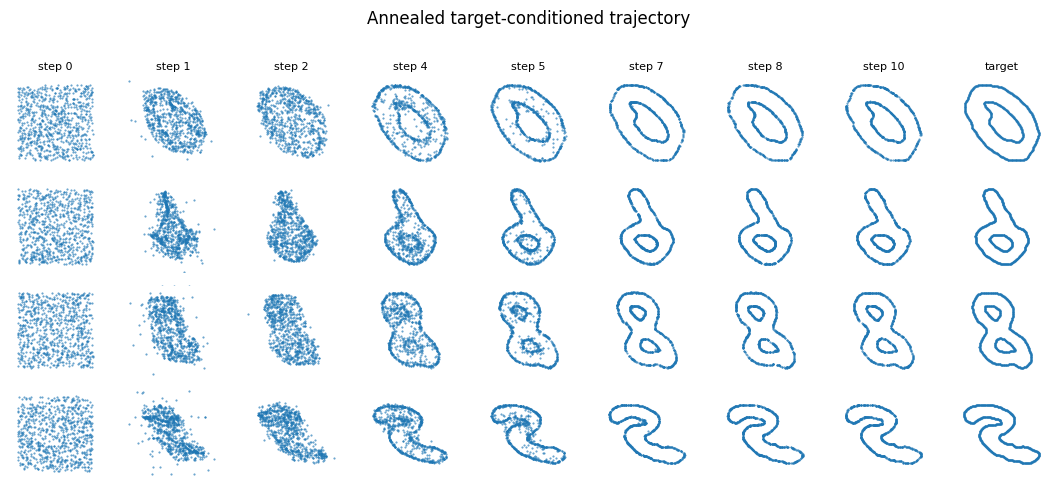

In [18]:
# Optional trajectory visualization for the first few reconstructions.
if reconstruction.trajectories is not None:
    traj = reconstruction.trajectories
    chosen_times = np.linspace(0, traj.shape[0] - 1, min(8, traj.shape[0]), dtype=int)
    rows = min(4, traj.shape[1])
    fig, axes = plt.subplots(rows, len(chosen_times) + 1, figsize=(1.2 * (len(chosen_times) + 1), 1.2 * rows), squeeze=False)
    for row in range(rows):
        for col, t_idx in enumerate(chosen_times):
            ax = axes[row, col]
            pts = traj[t_idx, row]
            ax.scatter(pts[:, 0], pts[:, 1], s=0.25 if pts.shape[0] > 300 else 0.8, alpha=0.75)
            ax.set_aspect("equal")
            ax.set_xlim(-0.10, 1.10)
            ax.set_ylim(1.10, -0.10)
            ax.axis("off")
            if row == 0:
                ax.set_title(f"step {t_idx}", fontsize=8)
        ax = axes[row, -1]
        pts = val_pc.positions[recon_idx[row]]
        ax.scatter(pts[:, 0], pts[:, 1], s=0.25 if pts.shape[0] > 300 else 0.8, alpha=0.75)
        ax.set_aspect("equal")
        ax.set_xlim(-0.10, 1.10)
        ax.set_ylim(1.10, -0.10)
        ax.axis("off")
        if row == 0:
            ax.set_title("target", fontsize=8)
    fig.suptitle("Annealed target-conditioned trajectory", y=1.01)
    plt.tight_layout()


## Latent prior: class-conditional Gaussian baseline

In [19]:
train_latents = encode_target_latents(
    score_model,
    train_pc.masses,
    train_pc.positions,
    batch_size=SCORE_BATCH_SIZE,
    device=DEVICE,
)
print("train latents:", train_latents.shape)
latent_prior = fit_gaussian_latent_prior(
    train_latents,
    train_pc.labels,
    diagonal=GAUSSIAN_LATENT_DIAGONAL,
    eps=1e-4,
)
print("latent prior components:", latent_prior.num_components, "latent_dim:", latent_prior.latent_dim)


train latents: (20000, 128)
latent prior components: 10 latent_dim: 128


,value
mmd_cd_macro,0.020428
coverage_cd_macro,0.093750
one_nn_cd_accuracy_macro,1.000000


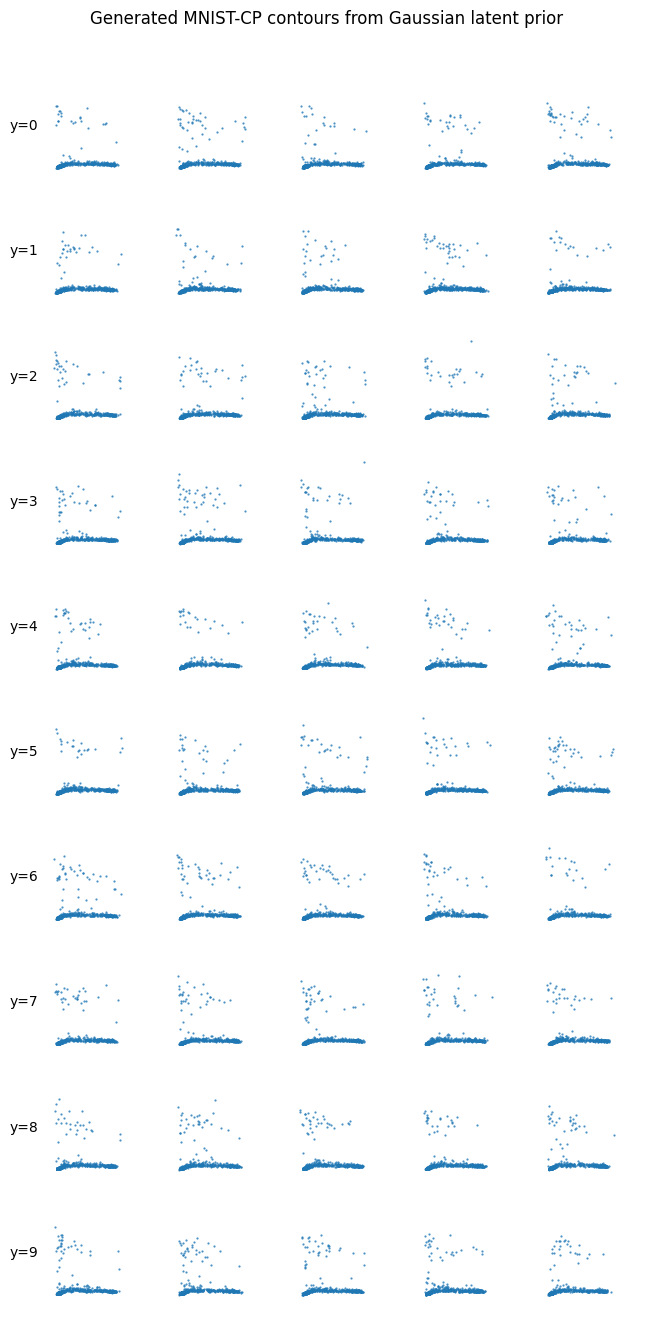

In [20]:
def balanced_labels(num_per_class: int, *, num_classes: int = 10) -> np.ndarray:
    return np.repeat(np.arange(num_classes, dtype=np.int64), int(num_per_class))


def generation_chamfer_metrics(generated: GeneratedPointCloudSet, reference_positions: np.ndarray, reference_labels: np.ndarray, *, max_per_class: int = 32, seed: int = 0) -> dict[str, object]:
    rng = np.random.default_rng(seed)
    per_label = {}
    one_nn_values = []
    coverage_values = []
    mmd_values = []
    for label in np.unique(generated.labels):
        gen_idx = np.flatnonzero(generated.labels == label)
        ref_idx = np.flatnonzero(reference_labels == label)
        if len(gen_idx) == 0 or len(ref_idx) == 0:
            continue
        gen_idx = rng.choice(gen_idx, size=min(max_per_class, len(gen_idx)), replace=False)
        ref_idx = rng.choice(ref_idx, size=min(max_per_class, len(ref_idx)), replace=False)
        gen_x = generated.positions[gen_idx]
        ref_x = reference_positions[ref_idx]
        rg = pairwise_chamfer_distance_matrix(ref_x, gen_x, squared=True)
        one_nn = one_nn_leave_one_out_chamfer(ref_x, gen_x, squared=True)
        cov = coverage_unique_argmin_chamfer(ref_x, gen_x, squared=True)
        mmd = float(np.mean(np.min(rg, axis=1)))
        per_label[int(label)] = {
            "mmd_cd": mmd,
            "coverage_cd": float(cov["coverage"]),
            "one_nn_cd_accuracy": float(one_nn["accuracy"]),
        }
        mmd_values.append(mmd)
        coverage_values.append(float(cov["coverage"]))
        one_nn_values.append(float(one_nn["accuracy"]))
    return {
        "mmd_cd_macro": float(np.mean(mmd_values)),
        "coverage_cd_macro": float(np.mean(coverage_values)),
        "one_nn_cd_accuracy_macro": float(np.mean(one_nn_values)),
        "per_label": per_label,
    }


gen_labels = balanced_labels(SYNTHETIC_PER_CLASS)
gaussian_z, gaussian_y = sample_gaussian_latent_prior(
    latent_prior,
    labels=gen_labels,
    rng=np.random.default_rng(SEED + 20),
)
gaussian_generated = sample_target_conditioned_annealed_dynamics(
    score_model,
    target_latents=gaussian_z,
    labels=gaussian_y,
    num_points=K,
    tau_levels=tau_levels,
    steps_per_level=STEPS_PER_LEVEL,
    sampler_scheme=SAMPLER_SCHEME,
    initial_position_mode="uniform",
    state_projection=STATE_PROJECTION,
    score_scale=SCORE_SCALE,
    diffusion_temperature=DIFFUSION_TEMPERATURE,
    final_polish_steps=FINAL_POLISH_STEPS,
    langevin_alpha=LANGEVIN_ALPHA,
    score_calibration=score_calibration,
    score_norm_clip=score_norm_clip,
    batch_size=SCORE_BATCH_SIZE,
    rasterize=False,
    device=DEVICE,
    rng=np.random.default_rng(SEED + 21),
)
plot_mnist_cp_gallery(
    gaussian_generated.positions,
    gaussian_generated.labels,
    examples_per_label=min(5, SYNTHETIC_PER_CLASS),
    title="Generated MNIST-CP contours from Gaussian latent prior",
    seed=SEED + 22,
)
gaussian_gen_metrics = generation_chamfer_metrics(
    gaussian_generated,
    reference_pc.positions,
    reference_pc.labels,
    max_per_class=min(32, SYNTHETIC_PER_CLASS),
    seed=SEED + 23,
)
pd.DataFrame([{k: v for k, v in gaussian_gen_metrics.items() if k != "per_label"}]).T.rename(columns={0: "value"})


## Optional latent prior: WGAN-GP over encoded `z`

In [21]:
if RUN_LATENT_WGAN:
    latent_generator = LatentGenerator(
        noise_dim=LATENT_NOISE_DIM,
        latent_dim=Z_DIM,
        hidden_dims=(256, 256),
        conditional=True,
        num_classes=10,
        label_embedding_dim=32,
        noise_std=0.2,
    )
    latent_critic = LatentCritic(
        latent_dim=Z_DIM,
        hidden_dims=(512, 512),
        conditional=True,
        num_classes=10,
        label_embedding_dim=32,
    )
    latent_wgan_history = train_latent_wgan_gp(
        latent_generator,
        latent_critic,
        train_latents,
        train_pc.labels,
        epochs=LATENT_WGAN_EPOCHS,
        batch_size=LATENT_WGAN_BATCH_SIZE,
        lr=LATENT_WGAN_LR,
        gradient_penalty_weight=LATENT_WGAN_GP,
        critic_steps=LATENT_WGAN_CRITIC_STEPS,
        device=DEVICE,
        verbose=True,
    )
else:
    latent_generator = None
    latent_critic = None
    latent_wgan_history = None
    print("Skipping latent WGAN. Set RUN_LATENT_WGAN=True to train it.")


Skipping latent WGAN. Set RUN_LATENT_WGAN=True to train it.


In [22]:
if latent_wgan_history is not None:
    fig = plt.figure(figsize=(6, 4))
    plt.plot(latent_wgan_history["critic_loss"], label="critic")
    plt.plot(latent_wgan_history["generator_loss"], label="generator")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Latent WGAN-GP training")
    plt.legend()
    plt.show()

if latent_generator is not None:
    wgan_z, wgan_y = sample_wgan_latent_prior(
        latent_generator,
        labels=gen_labels,
        device=DEVICE,
    )
    wgan_generated = sample_target_conditioned_annealed_dynamics(
        score_model,
        target_latents=wgan_z,
        labels=wgan_y,
        num_points=K,
        tau_levels=tau_levels,
        steps_per_level=STEPS_PER_LEVEL,
        sampler_scheme=SAMPLER_SCHEME,
        initial_position_mode="uniform",
        state_projection=STATE_PROJECTION,
        score_scale=SCORE_SCALE,
        diffusion_temperature=DIFFUSION_TEMPERATURE,
        final_polish_steps=FINAL_POLISH_STEPS,
        langevin_alpha=LANGEVIN_ALPHA,
        score_calibration=score_calibration,
        score_norm_clip=score_norm_clip,
        batch_size=SCORE_BATCH_SIZE,
        rasterize=False,
        device=DEVICE,
        rng=np.random.default_rng(SEED + 30),
    )
    plot_mnist_cp_gallery(
        wgan_generated.positions,
        wgan_generated.labels,
        examples_per_label=min(5, SYNTHETIC_PER_CLASS),
        title="Generated MNIST-CP contours from WGAN latent prior",
        seed=SEED + 31,
    )
    wgan_gen_metrics = generation_chamfer_metrics(
        wgan_generated,
        reference_pc.positions,
        reference_pc.labels,
        max_per_class=min(32, SYNTHETIC_PER_CLASS),
        seed=SEED + 32,
    )
    display(pd.DataFrame([{k: v for k, v in wgan_gen_metrics.items() if k != "per_label"}]).T.rename(columns={0: "value"}))
else:
    wgan_generated = None
    wgan_gen_metrics = None


## Suggested ablations

The most useful debugging sequence is:

- Compare neural reconstruction against the oracle empirical-mixture reconstruction. If the oracle works but the neural sampler collapses, improve score training/model coverage before tuning the latent prior.
- Compare `SAMPLER_SCHEME="shape_gf_langevin"` against `"theory_euler"`. The learned score is still a Wasserstein score, but the ShapeGF-style sampler is a more robust coarse-to-fine numerical method.
- Set `DIRECT_MIXTURE_PROBABILITY=0.0` to recover pure paired DSM. Collapse from a uniform prior should usually get worse.
- Set `USE_MEASURE_RESIDUAL=False` to test a pure concatenated full-measure score head. The default gated-residual version keeps the theoretical dependence on the current measure while preventing the current off-distribution cloud from dominating early sampling.
- Only turn `RUN_LATENT_WGAN=True` after real-`z` reconstruction and Gaussian-prior generation are visually acceptable.

For reporting, prioritize paired reconstruction CD for the autoencoding stage and MMD/COV/1-NNA Chamfer for latent-prior generation. Classifier accuracy is less central here than contour geometry.